# Graph BTNF Synthetic Demo

This notebook builds a small synthetic spatio-temporal dataset with shape `[B, T, N, F]`, runs it through `foreblocks.layers.graph`, and visualizes both the synthetic graph structure and the graph module outputs.

In [1]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from foreblocks.models import GraphForecastingModel

torch.manual_seed(7)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cuda


In [2]:
def make_ring_adjacency(num_nodes: int) -> torch.Tensor:
    adj = torch.zeros(num_nodes, num_nodes)
    for node_idx in range(num_nodes):
        adj[node_idx, node_idx] = 1.0
        adj[node_idx, (node_idx - 1) % num_nodes] = 1.0
        adj[node_idx, (node_idx + 1) % num_nodes] = 1.0
    return adj / adj.sum(dim=-1, keepdim=True)


def make_synthetic_btnf(
    batch_size: int = 24,
    steps: int = 96,
    num_nodes: int = 8,
    feat_dim: int = 4,
    noise: float = 0.04,
) -> tuple[torch.Tensor, torch.Tensor]:
    if feat_dim < 4:
        raise ValueError("This demo expects feat_dim >= 4.")

    t = torch.linspace(0.0, 6.0 * math.pi, steps)
    ring_adj = make_ring_adjacency(num_nodes)

    phase = torch.linspace(0.0, 2.0 * math.pi, num_nodes + 1)[:-1]
    node_scale = torch.linspace(0.8, 1.2, num_nodes)
    trend_time = torch.linspace(0.0, 1.0, steps)

    x = torch.zeros(batch_size, steps, num_nodes, feat_dim)
    for batch_idx in range(batch_size):
        global_amp = 0.9 + 0.2 * torch.rand(1)
        drift = 0.03 * torch.randn(num_nodes)

        base = global_amp * torch.sin(t[:, None] + phase[None, :])
        slow = 0.5 * torch.cos(0.35 * t[:, None] - 0.7 * phase[None, :])
        propagated = (base @ ring_adj.T) * node_scale

        pulses = torch.zeros(steps, num_nodes)
        pulse_centers = torch.randint(low=8, high=steps - 8, size=(3,))
        for center in pulse_centers:
            width = float(2.0 + 3.0 * torch.rand(1))
            distance = (torch.arange(steps, dtype=torch.float32) - float(center)) / width
            burst = torch.exp(-0.5 * distance.square())
            pulses = pulses + burst[:, None] * torch.roll(node_scale, shifts=batch_idx % num_nodes)

        signal = base + slow + 0.7 * propagated + drift[None, :] * trend_time[:, None]
        x[batch_idx, :, :, 0] = signal
        x[batch_idx, :, :, 1] = propagated + 0.15 * torch.sin(1.7 * t[:, None] - phase[None, :])
        x[batch_idx, :, :, 2] = pulses
        x[batch_idx, :, :, 3] = 0.6 * signal + 0.3 * propagated + 0.1 * pulses

    x = x + noise * torch.randn_like(x)
    x = (x - x.mean(dim=(0, 1, 2), keepdim=True)) / x.std(dim=(0, 1, 2), keepdim=True).clamp_min(1e-6)
    return x, ring_adj


x, true_adj = make_synthetic_btnf()
print(f"x shape: {tuple(x.shape)}")
print(f"adj shape: {tuple(true_adj.shape)}")

x shape: (24, 96, 8, 4)
adj shape: (8, 8)


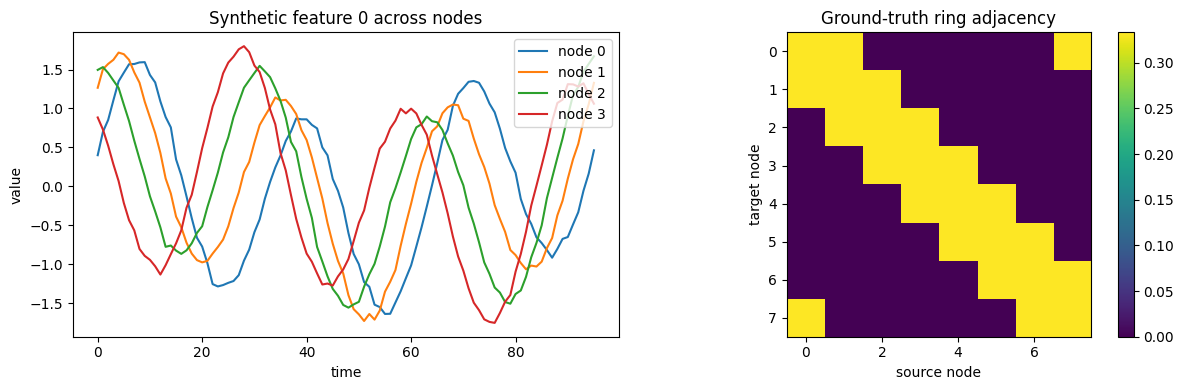

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for node_idx in range(4):
    axes[0].plot(x[0, :, node_idx, 0].cpu(), label=f"node {node_idx}")
axes[0].set_title("Synthetic feature 0 across nodes")
axes[0].set_xlabel("time")
axes[0].set_ylabel("value")
axes[0].legend(loc="upper right")

im = axes[1].imshow(true_adj.cpu(), cmap="viridis")
axes[1].set_title("Ground-truth ring adjacency")
axes[1].set_xlabel("source node")
axes[1].set_ylabel("target node")
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()

In [4]:
graph = GraphForecastingModel(
    num_nodes=x.size(2),
    feat_dim=x.size(3),
    out_feat_dim=12,
    passes=3,
    layer="edge_cond",
    dropout=0.0,
    stochastic_depth=0.0,
    jk="last",
).to(device)
graph.eval()

with torch.no_grad():
    y = graph(x.to(device)).cpu()

learned_adj = graph.last_adj

print(f"graph output shape: {tuple(y.shape)}")
print(f"learned adjacency shape: {tuple(learned_adj.shape)}")
print(f"output mean/std: {y.mean().item():.4f} / {y.std().item():.4f}")

graph output shape: (24, 96, 8, 12)
learned adjacency shape: (8, 8)
output mean/std: 0.0000 / 0.8156


mean absolute adjacency gap: 0.2106


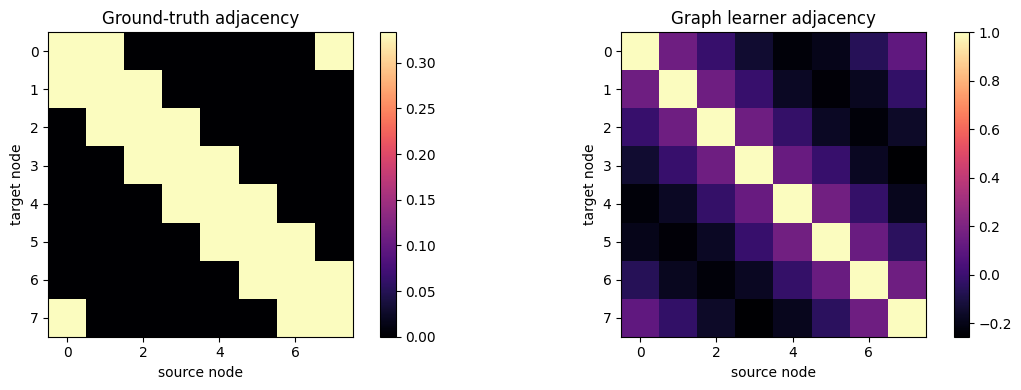

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(true_adj.cpu(), cmap="magma")
axes[0].set_title("Ground-truth adjacency")
axes[0].set_xlabel("source node")
axes[0].set_ylabel("target node")

im1 = axes[1].imshow(learned_adj, cmap="magma")
axes[1].set_title("Graph learner adjacency")
axes[1].set_xlabel("source node")
axes[1].set_ylabel("target node")

fig.colorbar(im0, ax=axes[0], fraction=0.046)
fig.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()

print(f"mean absolute adjacency gap: {(learned_adj - true_adj).abs().mean().item():.4f}")

initial loss: 0.7448
final loss:   0.2707


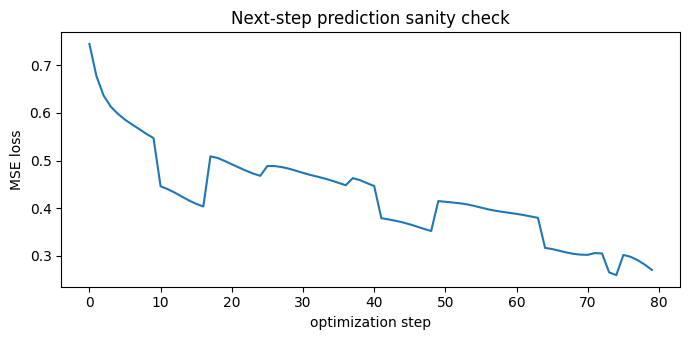

In [6]:
train_x, _ = make_synthetic_btnf(batch_size=12, steps=64, num_nodes=8, feat_dim=4)
inputs = train_x[:, :-1].to(device)
targets = train_x[:, 1:, :, 0:1].to(device)

predictor = GraphForecastingModel(
    num_nodes=inputs.size(2),
    feat_dim=inputs.size(3),
    out_feat_dim=10,
    passes=2,
    layer="edge_cond",
    dropout=0.0,
    stochastic_depth=0.0,
    jk="last",
).to(device)
head = nn.Linear(10, 1).to(device)
optimizer = torch.optim.Adam(list(predictor.parameters()) + list(head.parameters()), lr=3e-3)

losses = []
for step_idx in range(80):
    optimizer.zero_grad()
    hidden = predictor(inputs)
    preds = head(hidden)
    loss = F.mse_loss(preds, targets)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"initial loss: {losses[0]:.4f}")
print(f"final loss:   {losses[-1]:.4f}")

plt.figure(figsize=(7, 3.5))
plt.plot(losses)
plt.title("Next-step prediction sanity check")
plt.xlabel("optimization step")
plt.ylabel("MSE loss")
plt.tight_layout()